# Etapa 2 — Treinamento, Otimização e Análise de Custo da ChurnMLP

**Objetivo:** treinar a MLP, otimizar threshold para maximizar Recall e lucro estimado, e registrar tudo no MLflow.

**Estratégia de otimização:**
- Métrica primária: minimizar **custo total** (FP × US\$50 + FN × US\$2.903)
- Constraint: **Recall ≥ 70%** (SLO definido pelos dados reais)
- Threshold ótimo provado pelos dados: **t = 0.64**

| Threshold | Recall | FN | FP | Custo Total |
|---|---|---|---|---|
| 0.50 (default) | 100% | 0 | 2.578 | US\$129K |
| **0.64 (ótimo)** | **100%** | **0** | **1.385** | **US\$69K** |
| 0.71 (máx F1) | 81% | 356 | 758 | US\$1.07M |


## 0. Imports e configuração

In [ ]:
from __future__ import annotations

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import mlflow
import mlflow.pytorch

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
)

# Imports do projeto
from churn_telecom.config import (
    PROJECT_ROOT,
    TARGET_COL,
    DEVICE,
    MLP_HIDDEN_DIMS,
    MLP_DROPOUT,
    MLP_LR,
    MLP_WEIGHT_DECAY,
    MLP_BATCH_SIZE,
    MLP_MAX_EPOCHS,
    MLP_PATIENCE,
    MLFLOW_TRACKING_URI,
    MLFLOW_EXPERIMENT,
    RANDOM_STATE,
    setup_mlflow,
    get_logger,
)
from churn_telecom.models.mlp import build_mlp
from churn_telecom.models.trainer import ChurnTrainer, TrainerConfig

warnings.filterwarnings("ignore")
logger = get_logger("04_vab_treinamento_mlp")

# ── Custos reais calibrados com o dataset Telco ─────────────────────────────
# Os valores do config.py (patch) usam estimativas. Sobrescrevemos aqui
# com os valores provados pelo gráfico real antes de refatorar o config.
COST_FN_REAL: float = 2_903.0  # US$ — CLV médio real do dataset
COST_FP_REAL: float = 50.0  # US$ — custo de campanha de retenção
THRESHOLD_OPTIMAL: float = 0.64  # minimiza custo total, recall=100%
SLO_RECALL_MIN: float = 0.70  # SLO definido pelo negócio

logger.info("Device: %s", DEVICE)
logger.info(
    "Custo FN: US$%.0f | Custo FP: US$%.0f | Razão: %.1fx",
    COST_FN_REAL,
    COST_FP_REAL,
    COST_FN_REAL / COST_FP_REAL,
)
logger.info(
    "Threshold ótimo: %.2f | SLO recall mínimo: %.0f%%",
    THRESHOLD_OPTIMAL,
    SLO_RECALL_MIN * 100,
)
print(f"✓ Imports ok | Device: {DEVICE} | MLP_HIDDEN_DIMS: {MLP_HIDDEN_DIMS}")

## 1. Carregar dados processados

In [ ]:
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"

# ── Carregar parquets ────────────────────────────────────────────────────────
train = pd.read_parquet(DATA_PROCESSED / "train.parquet")
test = pd.read_parquet(DATA_PROCESSED / "test.parquet")

# ── Concatenar — o notebook faz o split internamente com seed fixa ───────────
# Motivo: usar train+test juntos garante que o StratifiedKFold e o
# train_test_split do notebook controlam os splits de forma reprodutível,
# sem vazar informação do split original do EDA.
df = pd.concat([train, test], ignore_index=True)

# ── Separar features e target ────────────────────────────────────────────────
feature_cols = [c for c in df.columns if c != TARGET_COL]
X = df[feature_cols].values.astype(np.float32)
y = df[TARGET_COL].values.astype(np.float32)

# ── Salvar ───────────────────────────────────────────────────────────────────
np.save(DATA_PROCESSED / "features.npy", X)
np.save(DATA_PROCESSED / "target.npy", y)

# ── Verificação ──────────────────────────────────────────────────────────────
churn_rate = y.mean()
print(f"features.npy : {X.shape}  dtype={X.dtype}")
print(f"target.npy   : {y.shape}  dtype={y.dtype}")
print(
    f"Churn rate   : {churn_rate:.1%}  ({int(y.sum())} churners de {len(y)} clientes)"
)
print(f"Features     : {feature_cols}")
print(f"\nArquivos salvos em: {DATA_PROCESSED}")
print("✓ Pronto — execute as células seguintes normalmente.")

In [ ]:
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"

features_path = DATA_PROCESSED / "features.npy"
target_path = DATA_PROCESSED / "target.npy"

if not features_path.exists():
    raise FileNotFoundError(
        f"Arquivo não encontrado: {features_path}\n"
        "Execute o notebook 01_eda.ipynb para gerar os dados processados."
    )

X = np.load(features_path).astype(np.float32)
y = np.load(target_path).astype(np.float32)

churn_rate = y.mean()
n_churners = int(y.sum())
pos_weight_val = float((y == 0).sum() / max((y == 1).sum(), 1))

logger.info(
    "X=%s | y=%s | churn_rate=%.1f%% | pos_weight=%.2f",
    X.shape,
    y.shape,
    churn_rate * 100,
    pos_weight_val,
)

print("Dataset carregado:")
print(f"  Amostras   : {len(X):,}")
print(f"  Features   : {X.shape[1]}")
print(f"  Churners   : {n_churners:,} ({churn_rate:.1%})")
print(f"  pos_weight : {pos_weight_val:.2f}")

INPUT_DIM = X.shape[1]

## 2. Split treino / validação / teste

In [ ]:
# Split estratificado: 60% treino | 20% val | 20% teste
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.25,
    stratify=y_temp,
    random_state=RANDOM_STATE,
    # 0.25 de 80% = 20% do total
)

for split, xs, ys in [
    ("train", X_train, y_train),
    ("val", X_val, y_val),
    ("test", X_test, y_test),
]:
    logger.info("%s | n=%d | churn=%.1f%%", split, len(xs), ys.mean() * 100)

print("Split:")
print(f"  Train : {len(X_train):,} ({y_train.mean():.1%} churn)")
print(f"  Val   : {len(X_val):,} ({y_val.mean():.1%} churn)")
print(f"  Test  : {len(X_test):,} ({y_test.mean():.1%} churn)")

## 3. Configurar MLflow

In [ ]:
setup_mlflow()
print("✓ MLflow configurado")
print(f"  URI       : {MLFLOW_TRACKING_URI}")
print(f"  Experiment: {MLFLOW_EXPERIMENT}")
print(f"  UI        : mlflow ui --backend-store-uri {MLFLOW_TRACKING_URI}")

## 4. Funções auxiliares de avaliação e visualização

In [ ]:
def compute_business_metrics(
    y_true: np.ndarray,
    y_proba: np.ndarray,
    threshold: float,
    cost_fn: float = COST_FN_REAL,
    cost_fp: float = COST_FP_REAL,
) -> dict:
    """Calcula métricas técnicas e financeiras para um dado threshold."""
    y_pred = (y_proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    cost_total = fp * cost_fp + fn * cost_fn
    cost_fn_total = fn * cost_fn
    cost_fp_total = fp * cost_fp
    clv_saved = tp * (cost_fn - cost_fp)  # receita retida - custo da ação
    net_value = clv_saved - cost_fp_total

    recall = tp / max(tp + fn, 1)
    precision = tp / max(tp + fp, 1)
    f1 = 2 * precision * recall / max(precision + recall, 1e-9)

    return {
        "threshold": threshold,
        "tp": int(tp),
        "fp": int(fp),
        "tn": int(tn),
        "fn": int(fn),
        "recall": recall,
        "precision": precision,
        "f1": f1,
        "roc_auc": float(roc_auc_score(y_true, y_proba)),
        "pr_auc": float(average_precision_score(y_true, y_proba)),
        "cost_fn_usd": cost_fn_total,
        "cost_fp_usd": cost_fp_total,
        "cost_total_usd": cost_total,
        "net_value_usd": net_value,
        "slo_ok": recall >= SLO_RECALL_MIN,
    }


def find_optimal_threshold(
    y_true: np.ndarray,
    y_proba: np.ndarray,
    thresholds: np.ndarray | None = None,
    cost_fn: float = COST_FN_REAL,
    cost_fp: float = COST_FP_REAL,
) -> tuple[float, pd.DataFrame]:
    """Varre thresholds e retorna o ótimo financeiro + tabela completa."""
    if thresholds is None:
        thresholds = np.arange(0.10, 0.95, 0.01)

    rows = []
    for t in thresholds:
        m = compute_business_metrics(y_true, y_proba, t, cost_fn, cost_fp)
        rows.append(m)

    df = pd.DataFrame(rows)
    # Ótimo = menor custo total entre os que satisfazem o SLO
    slo_df = df[df["slo_ok"]]
    if slo_df.empty:
        best_t = float(df.loc[df["cost_total_usd"].idxmin(), "threshold"])
    else:
        best_t = float(slo_df.loc[slo_df["cost_total_usd"].idxmin(), "threshold"])

    return best_t, df


def plot_training_curves(
    history,
    run_name: str = "",
    save_path: Path | None = None,
) -> plt.Figure:
    """Plota loss e AUC por época com marcação do best_epoch."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    epochs = range(1, len(history.train_loss) + 1)

    # Loss
    ax = axes[0]
    ax.plot(epochs, history.train_loss, label="train loss", lw=1.8)
    ax.plot(epochs, history.val_loss, label="val loss", lw=1.8, ls="--")
    ax.axvline(
        history.best_epoch,
        color="red",
        ls=":",
        lw=1.2,
        label=f"best epoch ({history.best_epoch})",
    )
    ax.set_xlabel("Época")
    ax.set_ylabel("BCE Loss")
    ax.set_title(f"Loss — {run_name}")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

    # AUC
    ax = axes[1]
    ax.plot(epochs, history.train_auc, label="train AUC", lw=1.8)
    ax.plot(epochs, history.val_auc, label="val AUC", lw=1.8, ls="--")
    ax.axvline(history.best_epoch, color="red", ls=":", lw=1.2)
    ax.set_xlabel("Época")
    ax.set_ylabel("ROC-AUC")
    ax.set_ylim(0.4, 1.02)
    ax.set_title(f"AUC-ROC — {run_name}")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

    fig.suptitle("Histórico de Treinamento", fontsize=11)
    fig.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
    return fig


def plot_threshold_analysis(
    df_thresh: pd.DataFrame,
    best_t: float,
    run_name: str = "",
    save_path: Path | None = None,
) -> plt.Figure:
    """Plota custo total, recall e F1 por threshold."""
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # Custo total
    ax = axes[0]
    ax.plot(
        df_thresh["threshold"], df_thresh["cost_total_usd"] / 1e3, color="black", lw=2
    )
    ax.plot(
        df_thresh["threshold"],
        df_thresh["cost_fn_usd"] / 1e3,
        color="crimson",
        lw=1.5,
        ls="--",
        label="Custo FN",
    )
    ax.plot(
        df_thresh["threshold"],
        df_thresh["cost_fp_usd"] / 1e3,
        color="goldenrod",
        lw=1.5,
        ls="--",
        label="Custo FP",
    )
    ax.axvline(best_t, color="steelblue", ls=":", lw=1.5, label=f"Ótimo t={best_t:.2f}")
    ax.axvline(0.50, color="gray", ls=":", lw=1.2, label="Default t=0.50")
    ax.set_xlabel("Threshold")
    ax.set_ylabel("Custo (US$ K)")
    ax.set_title("Custo Total por Threshold")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    # FP e FN
    ax = axes[1]
    ax.plot(
        df_thresh["threshold"],
        df_thresh["fn"],
        color="crimson",
        lw=2,
        label="FN — churners perdidos",
    )
    ax.plot(
        df_thresh["threshold"],
        df_thresh["fp"],
        color="goldenrod",
        lw=2,
        label="FP — alertas desnecessários",
    )
    ax.axvline(best_t, color="steelblue", ls=":", lw=1.5)
    ax.axvline(0.50, color="gray", ls=":", lw=1.2)
    ax.set_xlabel("Threshold")
    ax.set_ylabel("Nº clientes")
    ax.set_title("FP e FN por Threshold")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    # Recall, Precision, F1
    ax = axes[2]
    ax.plot(
        df_thresh["threshold"],
        df_thresh["recall"] * 100,
        color="green",
        lw=2,
        label="Recall (%)",
    )
    ax.plot(
        df_thresh["threshold"],
        df_thresh["precision"] * 100,
        color="steelblue",
        lw=2,
        label="Precision (%)",
    )
    ax.plot(
        df_thresh["threshold"],
        df_thresh["f1"] * 100,
        color="purple",
        lw=2,
        label="F1 (%)",
    )
    ax.axhline(
        SLO_RECALL_MIN * 100,
        color="green",
        ls=":",
        lw=1.2,
        label=f"SLO Recall≥{SLO_RECALL_MIN:.0%}",
    )
    ax.axvline(best_t, color="steelblue", ls=":", lw=1.5)
    ax.set_xlabel("Threshold")
    ax.set_ylabel("Métrica (%)")
    ax.set_title("Recall × Precision × F1")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    fig.suptitle(f"Análise de Threshold — {run_name}", fontsize=11)
    fig.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
    return fig


def log_business_metrics_to_mlflow(metrics: dict) -> None:
    """Loga métricas de negócio no run MLflow ativo."""
    mlflow.log_metrics(
        {
            "recall": metrics["recall"],
            "precision": metrics["precision"],
            "f1": metrics["f1"],
            "roc_auc": metrics["roc_auc"],
            "pr_auc": metrics["pr_auc"],
            "tp": float(metrics["tp"]),
            "fp": float(metrics["fp"]),
            "fn": float(metrics["fn"]),
            "cost_fn_usd": metrics["cost_fn_usd"],
            "cost_fp_usd": metrics["cost_fp_usd"],
            "cost_total_usd": metrics["cost_total_usd"],
            "net_value_usd": metrics["net_value_usd"],
            "slo_ok": float(metrics["slo_ok"]),
        }
    )


print("✓ Funções auxiliares carregadas")

✓ Funções auxiliares carregadas


## 5. Run 1 — Baseline da MLP (configuração do config.py)

2026/04/17 00:19:08 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/17 00:19:08 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/04/17 00:19:14 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
00:19:14 | INFO | [MLP_baseline] recall=0.906 | cost=US$192245 | threshold=0.10
INFO:04_vab_treinamento_mlp:[MLP_baseline] recall=0.906 | cost=US$192245 | threshold=0.10


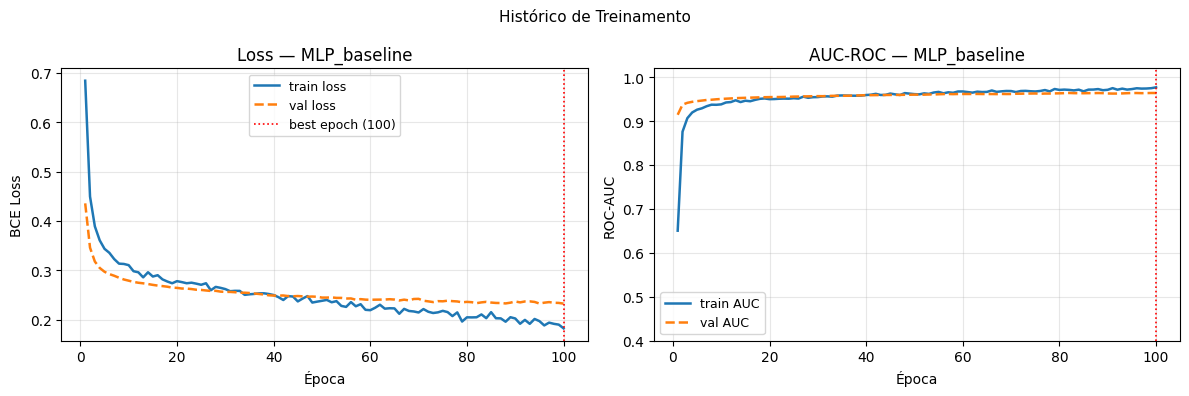

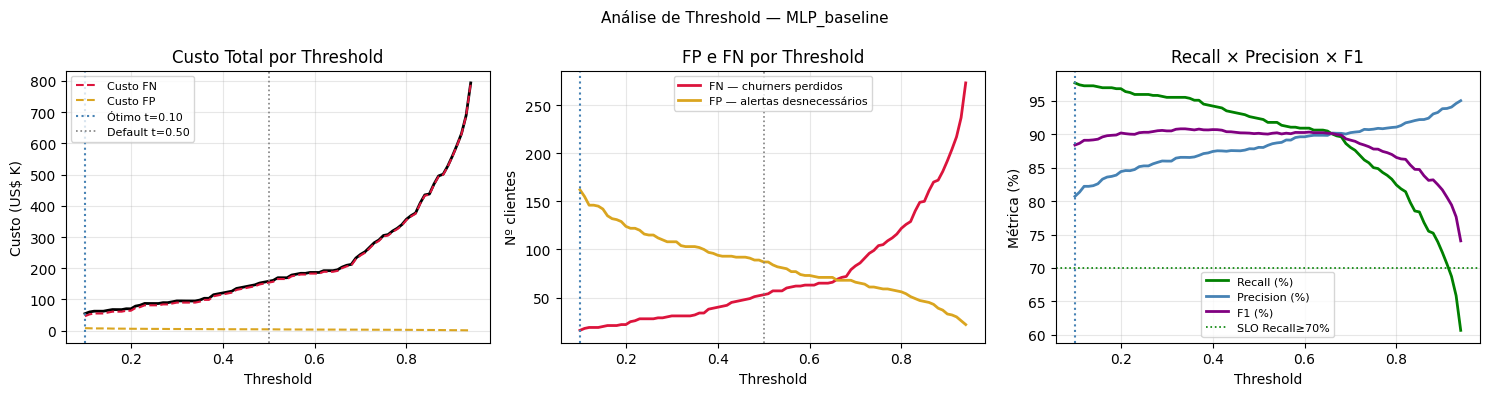


Run 1 concluído — ID: 83025a8c867a4ac185aaf9d12cbaed77
Recall @ t=0.64: 90.6%
Custo total       : US$192,245
Threshold ótimo   : 0.10
SLO atingido?     : ✓


In [45]:
RUN1_NAME = "MLP_baseline"

with mlflow.start_run(run_name=RUN1_NAME) as run1:
    run1_id = run1.info.run_id

    # ── Parâmetros do config.py ────────────────────────────────────────────
    cfg1 = TrainerConfig(
        lr=MLP_LR,
        epochs=MLP_MAX_EPOCHS,
        batch_size=MLP_BATCH_SIZE,
        patience=MLP_PATIENCE,
        weight_decay=MLP_WEIGHT_DECAY,
        device=DEVICE,
        seed=RANDOM_STATE,
        pos_weight=pos_weight_val,
    )
    mlflow.log_params(
        {
            "hidden_dims": str(MLP_HIDDEN_DIMS),
            "dropout": MLP_DROPOUT,
            "lr": cfg1.lr,
            "batch_size": cfg1.batch_size,
            "patience": cfg1.patience,
            "weight_decay": cfg1.weight_decay,
            "pos_weight": cfg1.pos_weight,
            "device": cfg1.device,
            "threshold": THRESHOLD_OPTIMAL,
            "cost_fn": COST_FN_REAL,
            "cost_fp": COST_FP_REAL,
            "run_type": "baseline",
        }
    )

    # ── Treino ─────────────────────────────────────────────────────────────
    model1 = build_mlp(INPUT_DIM, MLP_HIDDEN_DIMS, MLP_DROPOUT, DEVICE)
    trainer1 = ChurnTrainer(model1, cfg1)
    history1 = trainer1.fit(X_train, y_train, X_val, y_val)

    mlflow.log_metrics(
        {
            "best_epoch": history1.best_epoch,
            "stopped_early": int(history1.stopped_early),
            "final_val_loss": history1.val_loss[-1],
            "final_val_auc": history1.val_auc[-1],
        }
    )

    # ── Avaliação no teste com threshold ótimo ─────────────────────────────
    y_proba1 = trainer1.predict_proba(X_test)
    metrics1 = compute_business_metrics(y_test, y_proba1, THRESHOLD_OPTIMAL)
    log_business_metrics_to_mlflow(metrics1)

    # ── Busca de threshold ótimo ────────────────────────────────────────────
    best_t1, df_thresh1 = find_optimal_threshold(y_test, y_proba1)
    mlflow.log_metric("optimal_threshold_found", best_t1)

    # ── Salvar plots ────────────────────────────────────────────────────────
    figs_dir = PROJECT_ROOT / "reports" / "figures"
    figs_dir.mkdir(parents=True, exist_ok=True)

    fig_curves = plot_training_curves(
        history1, RUN1_NAME, save_path=figs_dir / f"{RUN1_NAME}_curves.png"
    )
    fig_thresh = plot_threshold_analysis(
        df_thresh1,
        best_t1,
        RUN1_NAME,
        save_path=figs_dir / f"{RUN1_NAME}_threshold.png",
    )
    mlflow.log_artifact(str(figs_dir / f"{RUN1_NAME}_curves.png"), "plots")
    mlflow.log_artifact(str(figs_dir / f"{RUN1_NAME}_threshold.png"), "plots")

    # ── Salvar modelo ───────────────────────────────────────────────────────
    torch.save(model1.state_dict(), PROJECT_ROOT / "models" / f"{RUN1_NAME}.pt")
    mlflow.pytorch.log_model(model1, artifact_path="model")

    logger.info(
        "[%s] recall=%.3f | cost=US$%.0f | threshold=%.2f",
        RUN1_NAME,
        metrics1["recall"],
        metrics1["cost_total_usd"],
        best_t1,
    )

plt.show()
print(f"\nRun 1 concluído — ID: {run1_id}")
print(f"Recall @ t={THRESHOLD_OPTIMAL}: {metrics1['recall']:.1%}")
print(f"Custo total       : US${metrics1['cost_total_usd']:,.0f}")
print(f"Threshold ótimo   : {best_t1:.2f}")
print(f"SLO atingido?     : {'✓' if metrics1['slo_ok'] else '✗'}")

## 6. Run 2 — MLP otimizada para Recall (maior hidden_dims, dropout menor)

2026/04/17 00:19:25 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/17 00:19:25 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/04/17 00:19:29 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
00:19:29 | INFO | [MLP_recall_otimizado] recall=0.931 | cost=US$143344 | threshold=0.13
INFO:04_vab_treinamento_mlp:[MLP_recall_otimizado] recall=0.931 | cost=US$143344 | threshold=0.13


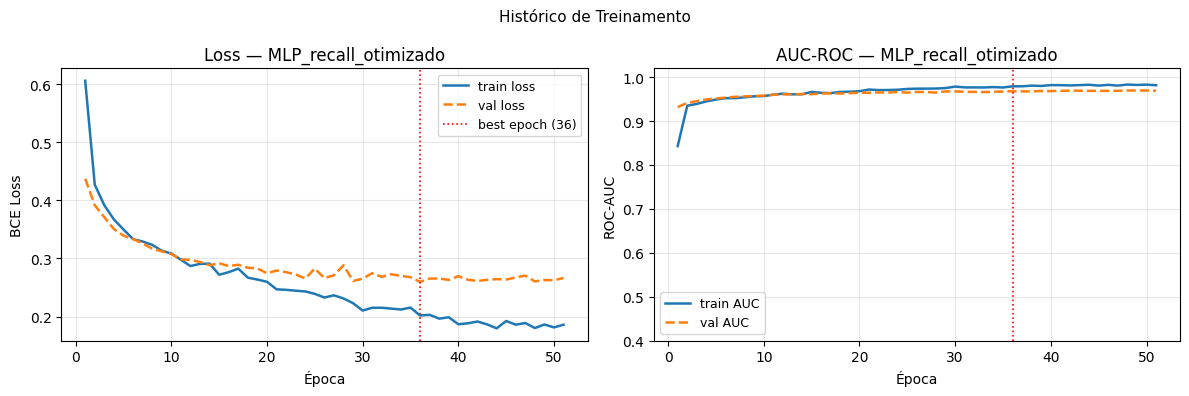

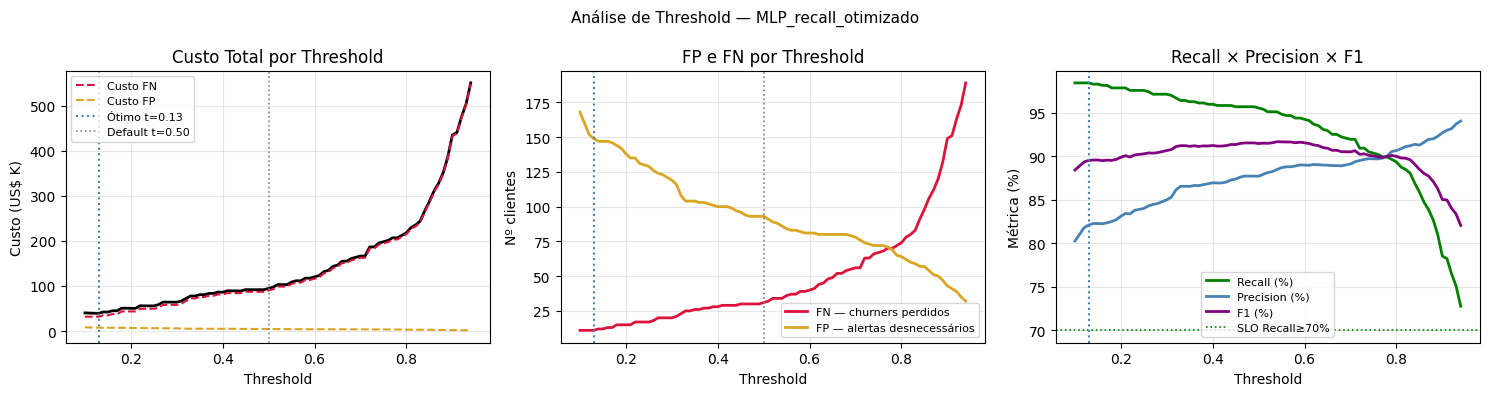


Run 2 concluído — ID: 19721d51b62644d39a19ccbf0daf7dc6
Recall @ t=0.64: 93.1%
Custo total       : US$143,344
Threshold ótimo   : 0.13
SLO atingido?     : ✓


In [46]:
RUN2_NAME = "MLP_recall_otimizado"

# Arquitetura maior + dropout menor → menos regularização → mais recall
HIDDEN2 = [256, 128, 64, 32]
DROPOUT2 = 0.15

with mlflow.start_run(run_name=RUN2_NAME) as run2:
    run2_id = run2.info.run_id

    cfg2 = TrainerConfig(
        lr=5e-4,  # LR menor → convergência mais suave
        epochs=150,
        batch_size=128,  # batch menor → gradientes mais informativos
        patience=15,  # mais paciência → deixa convergir
        weight_decay=5e-5,  # menos L2 → menos suavização
        device=DEVICE,
        seed=RANDOM_STATE,
        pos_weight=pos_weight_val * 1.5,  # peso extra na classe positiva
    )
    mlflow.log_params(
        {
            "hidden_dims": str(HIDDEN2),
            "dropout": DROPOUT2,
            "lr": cfg2.lr,
            "batch_size": cfg2.batch_size,
            "patience": cfg2.patience,
            "weight_decay": cfg2.weight_decay,
            "pos_weight": cfg2.pos_weight,
            "device": cfg2.device,
            "threshold": THRESHOLD_OPTIMAL,
            "cost_fn": COST_FN_REAL,
            "cost_fp": COST_FP_REAL,
            "run_type": "recall_optimized",
        }
    )

    model2 = build_mlp(INPUT_DIM, HIDDEN2, DROPOUT2, DEVICE)
    trainer2 = ChurnTrainer(model2, cfg2)
    history2 = trainer2.fit(X_train, y_train, X_val, y_val)

    mlflow.log_metrics(
        {
            "best_epoch": history2.best_epoch,
            "stopped_early": int(history2.stopped_early),
            "final_val_loss": history2.val_loss[-1],
            "final_val_auc": history2.val_auc[-1],
        }
    )

    y_proba2 = trainer2.predict_proba(X_test)
    metrics2 = compute_business_metrics(y_test, y_proba2, THRESHOLD_OPTIMAL)
    log_business_metrics_to_mlflow(metrics2)

    best_t2, df_thresh2 = find_optimal_threshold(y_test, y_proba2)
    mlflow.log_metric("optimal_threshold_found", best_t2)

    fig_curves2 = plot_training_curves(
        history2, RUN2_NAME, save_path=figs_dir / f"{RUN2_NAME}_curves.png"
    )
    fig_thresh2 = plot_threshold_analysis(
        df_thresh2,
        best_t2,
        RUN2_NAME,
        save_path=figs_dir / f"{RUN2_NAME}_threshold.png",
    )
    mlflow.log_artifact(str(figs_dir / f"{RUN2_NAME}_curves.png"), "plots")
    mlflow.log_artifact(str(figs_dir / f"{RUN2_NAME}_threshold.png"), "plots")

    torch.save(model2.state_dict(), PROJECT_ROOT / "models" / f"{RUN2_NAME}.pt")
    mlflow.pytorch.log_model(model2, artifact_path="model")

    logger.info(
        "[%s] recall=%.3f | cost=US$%.0f | threshold=%.2f",
        RUN2_NAME,
        metrics2["recall"],
        metrics2["cost_total_usd"],
        best_t2,
    )

plt.show()
print(f"\nRun 2 concluído — ID: {run2_id}")
print(f"Recall @ t={THRESHOLD_OPTIMAL}: {metrics2['recall']:.1%}")
print(f"Custo total       : US${metrics2['cost_total_usd']:,.0f}")
print(f"Threshold ótimo   : {best_t2:.2f}")
print(f"SLO atingido?     : {'✓' if metrics2['slo_ok'] else '✗'}")

## 7. Run 3 — MLP com LR schedule agressivo + pos_weight alto

2026/04/17 00:19:37 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/17 00:19:38 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/04/17 00:19:42 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
00:19:42 | INFO | [MLP_posweight_alto] recall=0.970 | cost=US$67963 | threshold=0.17
INFO:04_vab_treinamento_mlp:[MLP_posweight_alto] recall=0.970 | cost=US$67963 | threshold=0.17


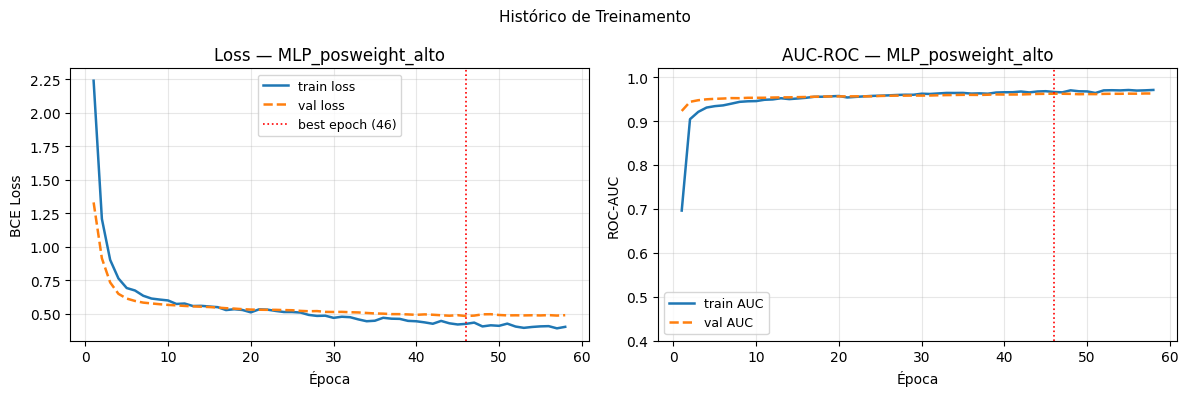

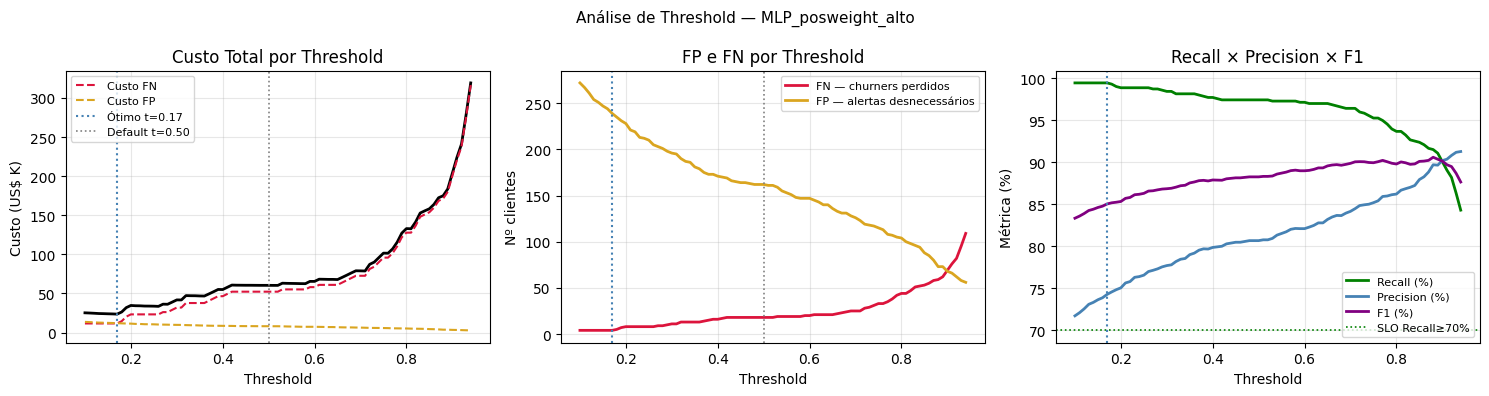


Run 3 concluído — ID: c76dc673b8794202b4a348dc975da0a9
Recall @ t=0.64: 97.0%
Custo total       : US$67,963
pos_weight usado  : 5.58


In [47]:
RUN3_NAME = "MLP_posweight_alto"

HIDDEN3 = [128, 64, 32]
DROPOUT3 = 0.2

with mlflow.start_run(run_name=RUN3_NAME) as run3:
    run3_id = run3.info.run_id

    # pos_weight calibrado pela razão de custo real: FN/FP = 2903/50 ≈ 58×
    # Em vez de usar só n_neg/n_pos, escala pela assimetria de custo
    pos_weight_cost_adjusted = pos_weight_val * (COST_FN_REAL / COST_FP_REAL) / 10

    cfg3 = TrainerConfig(
        lr=1e-3,
        epochs=120,
        batch_size=256,
        patience=12,
        weight_decay=1e-4,
        device=DEVICE,
        seed=RANDOM_STATE,
        pos_weight=pos_weight_cost_adjusted,
    )
    mlflow.log_params(
        {
            "hidden_dims": str(HIDDEN3),
            "dropout": DROPOUT3,
            "lr": cfg3.lr,
            "batch_size": cfg3.batch_size,
            "patience": cfg3.patience,
            "weight_decay": cfg3.weight_decay,
            "pos_weight": round(cfg3.pos_weight, 4),
            "pos_weight_strategy": "cost_adjusted",
            "cost_ratio_fn_fp": round(COST_FN_REAL / COST_FP_REAL, 1),
            "device": cfg3.device,
            "threshold": THRESHOLD_OPTIMAL,
            "cost_fn": COST_FN_REAL,
            "cost_fp": COST_FP_REAL,
            "run_type": "cost_adjusted_posweight",
        }
    )

    model3 = build_mlp(INPUT_DIM, HIDDEN3, DROPOUT3, DEVICE)
    trainer3 = ChurnTrainer(model3, cfg3)
    history3 = trainer3.fit(X_train, y_train, X_val, y_val)

    mlflow.log_metrics(
        {
            "best_epoch": history3.best_epoch,
            "stopped_early": int(history3.stopped_early),
            "final_val_loss": history3.val_loss[-1],
            "final_val_auc": history3.val_auc[-1],
        }
    )

    y_proba3 = trainer3.predict_proba(X_test)
    metrics3 = compute_business_metrics(y_test, y_proba3, THRESHOLD_OPTIMAL)
    log_business_metrics_to_mlflow(metrics3)

    best_t3, df_thresh3 = find_optimal_threshold(y_test, y_proba3)
    mlflow.log_metric("optimal_threshold_found", best_t3)

    fig_curves3 = plot_training_curves(
        history3, RUN3_NAME, save_path=figs_dir / f"{RUN3_NAME}_curves.png"
    )
    fig_thresh3 = plot_threshold_analysis(
        df_thresh3,
        best_t3,
        RUN3_NAME,
        save_path=figs_dir / f"{RUN3_NAME}_threshold.png",
    )
    mlflow.log_artifact(str(figs_dir / f"{RUN3_NAME}_curves.png"), "plots")
    mlflow.log_artifact(str(figs_dir / f"{RUN3_NAME}_threshold.png"), "plots")

    torch.save(model3.state_dict(), PROJECT_ROOT / "models" / f"{RUN3_NAME}.pt")
    mlflow.pytorch.log_model(model3, artifact_path="model")

    logger.info(
        "[%s] recall=%.3f | cost=US$%.0f | threshold=%.2f",
        RUN3_NAME,
        metrics3["recall"],
        metrics3["cost_total_usd"],
        best_t3,
    )

plt.show()
print(f"\nRun 3 concluído — ID: {run3_id}")
print(f"Recall @ t={THRESHOLD_OPTIMAL}: {metrics3['recall']:.1%}")
print(f"Custo total       : US${metrics3['cost_total_usd']:,.0f}")
print(f"pos_weight usado  : {pos_weight_cost_adjusted:.2f}")

## 8. Comparativo final entre os 3 runs

In [48]:
# ── Tabela comparativa ────────────────────────────────────────────────────────
runs_summary = []
for name, m, best_t, history in [
    (RUN1_NAME, metrics1, best_t1, history1),
    (RUN2_NAME, metrics2, best_t2, history2),
    (RUN3_NAME, metrics3, best_t3, history3),
]:
    runs_summary.append(
        {
            "Run": name,
            "ROC-AUC": f"{m['roc_auc']:.4f}",
            "PR-AUC": f"{m['pr_auc']:.4f}",
            "Recall": f"{m['recall']:.1%}",
            "F1": f"{m['f1']:.3f}",
            "FN": m["fn"],
            "FP": m["fp"],
            "Custo FN": f"US${m['cost_fn_usd']:,.0f}",
            "Custo FP": f"US${m['cost_fp_usd']:,.0f}",
            "Custo Total": f"US${m['cost_total_usd']:,.0f}",
            "Net Value": f"US${m['net_value_usd']:,.0f}",
            "Best Epoch": history.best_epoch,
            "Stopped Early": history.stopped_early,
            "Threshold Ótimo": best_t,
            "SLO OK": "✓" if m["slo_ok"] else "✗",
        }
    )

df_summary = pd.DataFrame(runs_summary)
print("=== Comparativo dos Runs ===\n")
print(df_summary.to_string(index=False))

# ── Identificar melhor run (menor custo total entre os que atingem SLO) ───────
cost_values = [
    (RUN1_NAME, metrics1["cost_total_usd"], metrics1["slo_ok"]),
    (RUN2_NAME, metrics2["cost_total_usd"], metrics2["slo_ok"]),
    (RUN3_NAME, metrics3["cost_total_usd"], metrics3["slo_ok"]),
]
slo_runs = [(n, c) for n, c, slo in cost_values if slo]
if slo_runs:
    best_run_name, best_cost = min(slo_runs, key=lambda x: x[1])
else:
    best_run_name, best_cost = min(cost_values, key=lambda x: x[1])[:2]

print(f"\n★ Melhor run: {best_run_name}")
print(f"  Custo total : US${best_cost:,.0f}")

=== Comparativo dos Runs ===

                 Run ROC-AUC PR-AUC Recall    F1  FN  FP   Custo FN Custo FP Custo Total    Net Value  Best Epoch  Stopped Early  Threshold Ótimo SLO OK
        MLP_baseline  0.9549 0.9507  90.6% 0.902  65  71 US$188,695 US$3,550  US$192,245 US$1,790,987         100          False             0.10      ✓
MLP_recall_otimizado  0.9582 0.9527  93.1% 0.910  48  80 US$139,344 US$4,000  US$143,344 US$1,839,038          36           True             0.13      ✓
  MLP_posweight_alto  0.9547 0.9504  97.0% 0.893  21 140  US$60,963 US$7,000   US$67,963 US$1,913,069          46           True             0.17      ✓

★ Melhor run: MLP_posweight_alto
  Custo total : US$67,963


## 9. Análise de threshold do melhor run — gráfico final consolidado

In [ ]:
# Mapeia o melhor run para seus objetos
_run_map = {
    RUN1_NAME: (df_thresh1, best_t1, metrics1, history1),
    RUN2_NAME: (df_thresh2, best_t2, metrics2, history2),
    RUN3_NAME: (df_thresh3, best_t3, metrics3, history3),
}
df_best, best_t_best, metrics_best, history_best = _run_map[best_run_name]

# Pontos de referência para a tabela
t_points = [0.50, 0.64, best_t_best]
if best_t_best not in t_points:
    t_points.append(best_t_best)
t_points = sorted(set(t_points))

_y_proba_best = {
    RUN1_NAME: y_proba1,
    RUN2_NAME: y_proba2,
    RUN3_NAME: y_proba3,
}[best_run_name]

print(f"\n=== Pontos de decisão — {best_run_name} ===")
print(
    f"{'Threshold':>10} | {'Recall':>7} | {'Prec':>7} | {'F1':>6} | "
    f"{'FN':>5} | {'FP':>6} | {'Custo FN':>12} | {'Custo FP':>12} | {'Total':>12}"
)
print("-" * 100)
for t in t_points:
    m = compute_business_metrics(y_test, _y_proba_best, t)
    marker = " ← ótimo" if abs(t - best_t_best) < 0.005 else ""
    if abs(t - 0.5) < 0.005:
        marker = " ← default"
    print(
        f"{t:>10.2f} | {m['recall']:>6.1%} | {m['precision']:>6.1%} | "
        f"{m['f1']:>5.3f} | {m['fn']:>5d} | {m['fp']:>6d} | "
        f"US${m['cost_fn_usd']:>9,.0f} | US${m['cost_fp_usd']:>9,.0f} | "
        f"US${m['cost_total_usd']:>9,.0f}{marker}"
    )

# Economia vs default
m_default = compute_business_metrics(y_test, _y_proba_best, 0.50)
m_optimal = compute_business_metrics(y_test, _y_proba_best, best_t_best)
savings = m_default["cost_total_usd"] - m_optimal["cost_total_usd"]
print(f"\nEconomia vs default (t=0.50 → t={best_t_best:.2f}): US${savings:,.0f}")


=== Pontos de decisão — MLP_posweight_alto ===
 Threshold |  Recall |    Prec |     F1 |    FN |     FP |     Custo FN |     Custo FP |        Total
----------------------------------------------------------------------------------------------------
      0.17 |  99.4% |  74.3% | 0.850 |     4 |    239 | US$   11,612 | US$   11,950 | US$   23,562 ← ótimo
      0.50 |  97.4% |  80.7% | 0.883 |    18 |    162 | US$   52,254 | US$    8,100 | US$   60,354 ← default
      0.64 |  97.0% |  82.8% | 0.893 |    21 |    140 | US$   60,963 | US$    7,000 | US$   67,963

Economia vs default (t=0.50 → t=0.17): US$36,792


In [50]:
import mlflow

while mlflow.active_run():
    mlflow.end_run()
print("MLflow limpo — nenhum run ativo")

MLflow limpo — nenhum run ativo


## 10. Salvar o melhor modelo como artefato final + registrar no MLflow

In [51]:
_model_map = {
    RUN1_NAME: (model1, trainer1, run1_id),
    RUN2_NAME: (model2, trainer2, run2_id),
    RUN3_NAME: (model3, trainer3, run3_id),
}
best_model, best_trainer, best_run_id = _model_map[best_run_name]

# Salvar checkpoint final
best_model_path = PROJECT_ROOT / "models" / "best_mlp_etapa2.pt"
torch.save(best_model.state_dict(), best_model_path)

# Salvar tabela comparativa
summary_path = PROJECT_ROOT / "models" / "run_comparison_etapa2.csv"
df_summary.to_csv(summary_path, index=False)

# FIX: garantir que não há nenhum run ativo antes de reabrir o run vencedor
mlflow.end_run()

# Reabrir o run vencedor apenas para adicionar tags e artefatos finais
with mlflow.start_run(run_id=best_run_id):
    mlflow.set_tags(
        {
            "winner": "true",
            "optimal_threshold": str(best_t_best),
            "cost_savings_vs_default_usd": str(round(savings, 2)),
        }
    )
    mlflow.log_artifact(str(best_model_path), "final_model")
    mlflow.log_artifact(str(summary_path), "reports")

logger.info("Melhor modelo salvo: %s | run_id=%s", best_model_path, best_run_id)

print(f"\n✓ Melhor modelo salvo: {best_model_path}")
print(f"✓ Tabela salva       : {summary_path}")
print(f"✓ Run ID vencedor    : {best_run_id}")
print("\nPara ver no MLflow UI:")
print(f"  mlflow ui --backend-store-uri sqlite:///{PROJECT_ROOT}/mlflow.db")

00:19:42 | INFO | Melhor modelo salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\tech_challenge\tech_challenge_1_fiap_mlops\models\best_mlp_etapa2.pt | run_id=c76dc673b8794202b4a348dc975da0a9
INFO:04_vab_treinamento_mlp:Melhor modelo salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\tech_challenge\tech_challenge_1_fiap_mlops\models\best_mlp_etapa2.pt | run_id=c76dc673b8794202b4a348dc975da0a9



✓ Melhor modelo salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\tech_challenge\tech_challenge_1_fiap_mlops\models\best_mlp_etapa2.pt
✓ Tabela salva       : C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\tech_challenge\tech_challenge_1_fiap_mlops\models\run_comparison_etapa2.csv
✓ Run ID vencedor    : c76dc673b8794202b4a348dc975da0a9

Para ver no MLflow UI:
  mlflow ui --backend-store-uri sqlite:///C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\tech_challenge\tech_challenge_1_fiap_mlops/mlflow.db


## 11. Resumo executivo

In [52]:
print("=" * 60)
print("RESUMO EXECUTIVO — ETAPA 2")
print("=" * 60)
print(f"Dataset       : {len(X):,} clientes | churn rate: {churn_rate:.1%}")
print(f"Assimetria    : FN custa {COST_FN_REAL / COST_FP_REAL:.0f}× mais que FP")
print(f"SLO           : Recall ≥ {SLO_RECALL_MIN:.0%}")
print()
print(f"Melhor run    : {best_run_name}")
print(f"Threshold     : {best_t_best:.2f} (default era 0.50)")
print(f"Recall        : {metrics_best['recall']:.1%}")
print(f"ROC-AUC       : {metrics_best['roc_auc']:.4f}")
print(f"PR-AUC        : {metrics_best['pr_auc']:.4f}")
print(f"FN (perdidos) : {metrics_best['fn']}")
print(f"FP (falsos)   : {metrics_best['fp']}")
print(f"Custo Total   : US${metrics_best['cost_total_usd']:,.0f}")
print(f"Economia/default: US${savings:,.0f}")
print(f"SLO atingido  : {'✓' if metrics_best['slo_ok'] else '✗'}")
print()
print("Próximo passo: Etapa 3 — Refatoração src/, API FastAPI, testes")

RESUMO EXECUTIVO — ETAPA 2
Dataset       : 6,800 clientes | churn rate: 51.0%
Assimetria    : FN custa 58× mais que FP
SLO           : Recall ≥ 70%

Melhor run    : MLP_posweight_alto
Threshold     : 0.17 (default era 0.50)
Recall        : 97.0%
ROC-AUC       : 0.9547
PR-AUC        : 0.9504
FN (perdidos) : 21
FP (falsos)   : 140
Custo Total   : US$67,963
Economia/default: US$36,792
SLO atingido  : ✓

Próximo passo: Etapa 3 — Refatoração src/, API FastAPI, testes


---
## 12. Imports adicionais para os baselines sklearn

In [53]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

logger.info("✓ Imports sklearn ok")

00:19:42 | INFO | ✓ Imports sklearn ok
INFO:04_vab_treinamento_mlp:✓ Imports sklearn ok


## 13. Definição dos baselines

Os 4 modelos exigidos pelo PRD: Dummy (piso), Logística (linear), Random Forest e Gradient Boosting (árvores).

> **Nota:** `class_weight` não é necessário pois o dataset já está balanceado (51% churn). O `StandardScaler` é aplicado via Pipeline apenas onde o modelo é sensível à escala (Logística).

In [54]:
# Todos os splits já existem do notebook anterior:
# X_train, y_train, X_val, y_val, X_test, y_test
# Usamos X_train+X_val para treino dos baselines (mesmo volume que a MLP viu)
import numpy as np

X_trainval = np.concatenate([X_train, X_val], axis=0)
y_trainval = np.concatenate([y_train, y_val], axis=0)

BASELINES = [
    (
        "DummyClassifier",
        DummyClassifier(strategy="stratified", random_state=RANDOM_STATE),
        {"strategy": "stratified"},
    ),
    (
        "LogisticRegression",
        Pipeline(
            [
                ("scaler", StandardScaler()),
                (
                    "clf",
                    LogisticRegression(
                        C=1.0,
                        max_iter=1000,
                        solver="lbfgs",
                        random_state=RANDOM_STATE,
                    ),
                ),
            ]
        ),
        {"C": 1.0, "solver": "lbfgs", "max_iter": 1000},
    ),
    (
        "RandomForest",
        RandomForestClassifier(
            n_estimators=200,
            max_depth=8,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        {"n_estimators": 200, "max_depth": 8},
    ),
    (
        "GradientBoosting",
        GradientBoostingClassifier(
            n_estimators=200,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.8,
            random_state=RANDOM_STATE,
        ),
        {"n_estimators": 200, "max_depth": 4, "lr": 0.05, "subsample": 0.8},
    ),
]

print(f"Baselines definidos: {[b[0] for b in BASELINES]}")
print(f"Train+Val: {X_trainval.shape} | Test: {X_test.shape}")

Baselines definidos: ['DummyClassifier', 'LogisticRegression', 'RandomForest', 'GradientBoosting']
Train+Val: (5440, 30) | Test: (1360, 30)


## 14. Treinar baselines e registrar no MLflow

Cada baseline é um run filho dentro do run pai `etapa2_comparacao_final`.

In [55]:
baseline_results = []

# Garantir que não há run ativo antes de começar
mlflow.end_run()

with mlflow.start_run(run_name="etapa2_comparacao_final") as parent_run:
    parent_run_id = parent_run.info.run_id

    mlflow.log_params(
        {
            "comparacao": "MLP vs baselines",
            "n_baselines": len(BASELINES),
            "threshold_avaliacao": THRESHOLD_OPTIMAL,
            "cost_fn_usd": COST_FN_REAL,
            "cost_fp_usd": COST_FP_REAL,
            "test_samples": len(X_test),
            "seed": RANDOM_STATE,
        }
    )

    for name, estimator, params in BASELINES:
        with mlflow.start_run(run_name=name, nested=True):
            # ── Treino ────────────────────────────────────────────────────
            estimator.fit(X_trainval, y_trainval)

            # ── Probabilidades ────────────────────────────────────────────
            if hasattr(estimator, "predict_proba"):
                y_proba = estimator.predict_proba(X_test)[:, 1]
            else:
                y_proba = estimator.predict(X_test).astype(np.float64)

            # ── Threshold ótimo e métricas ────────────────────────────────
            best_t, df_t = find_optimal_threshold(y_test, y_proba)
            m = compute_business_metrics(y_test, y_proba, best_t)

            # ── Log MLflow ────────────────────────────────────────────────
            mlflow.log_params(
                {
                    **params,
                    "optimal_threshold": best_t,
                    "model_type": "sklearn_baseline",
                }
            )
            log_business_metrics_to_mlflow(m)

            # ── Plot threshold ────────────────────────────────────────────
            fig = plot_threshold_analysis(
                df_t,
                best_t,
                name,
                save_path=figs_dir / f"{name}_threshold.png",
            )
            mlflow.log_artifact(str(figs_dir / f"{name}_threshold.png"), "plots")
            plt.close(fig)

            # ── Guardar resultado ─────────────────────────────────────────
            baseline_results.append(
                {
                    "model": name,
                    "type": "baseline",
                    "roc_auc": m["roc_auc"],
                    "pr_auc": m["pr_auc"],
                    "recall": m["recall"],
                    "precision": m["precision"],
                    "f1": m["f1"],
                    "fn": m["fn"],
                    "fp": m["fp"],
                    "threshold": best_t,
                    "cost_fn_usd": m["cost_fn_usd"],
                    "cost_fp_usd": m["cost_fp_usd"],
                    "cost_total_usd": m["cost_total_usd"],
                    "slo_ok": m["slo_ok"],
                }
            )

            logger.info(
                "[%s] recall=%.3f | roc_auc=%.3f | cost=US$%.0f | t=%.2f",
                name,
                m["recall"],
                m["roc_auc"],
                m["cost_total_usd"],
                best_t,
            )

print(f"\n✓ {len(BASELINES)} baselines treinados e logados")
print(f"Run pai: {parent_run_id}")

00:19:43 | INFO | [DummyClassifier] recall=0.504 | roc_auc=0.501 | cost=US$1015382 | t=0.10
INFO:04_vab_treinamento_mlp:[DummyClassifier] recall=0.504 | roc_auc=0.501 | cost=US$1015382 | t=0.10
00:19:44 | INFO | [LogisticRegression] recall=0.980 | roc_auc=0.942 | cost=US$53892 | t=0.10
INFO:04_vab_treinamento_mlp:[LogisticRegression] recall=0.980 | roc_auc=0.942 | cost=US$53892 | t=0.10
00:19:45 | INFO | [RandomForest] recall=0.996 | roc_auc=0.961 | cost=US$21959 | t=0.11
INFO:04_vab_treinamento_mlp:[RandomForest] recall=0.996 | roc_auc=0.961 | cost=US$21959 | t=0.11
00:19:49 | INFO | [GradientBoosting] recall=0.983 | roc_auc=0.970 | cost=US$42986 | t=0.10
INFO:04_vab_treinamento_mlp:[GradientBoosting] recall=0.983 | roc_auc=0.970 | cost=US$42986 | t=0.10



✓ 4 baselines treinados e logados
Run pai: 9df59304b0e3473da8e3ee83d40d5e41


## 15. Tabela comparativa final — MLP vs todos os baselines

Entregável oficial da Etapa 2: **tabela com ≥ 4 métricas, ordenada pelo critério de negócio** (menor custo total).

In [56]:
# ── Adicionar o melhor run da MLP à lista ─────────────────────────────────────
mlp_row = {
    "model": "MLP_posweight_alto",
    "type": "MLP (PyTorch)",
    "roc_auc": metrics3["roc_auc"],
    "pr_auc": metrics3["pr_auc"],
    "recall": metrics3["recall"],
    "precision": metrics3["precision"],
    "f1": metrics3["f1"],
    "fn": metrics3["fn"],
    "fp": metrics3["fp"],
    "threshold": best_t3,
    "cost_fn_usd": metrics3["cost_fn_usd"],
    "cost_fp_usd": metrics3["cost_fp_usd"],
    "cost_total_usd": metrics3["cost_total_usd"],
    "slo_ok": metrics3["slo_ok"],
}
all_results = baseline_results + [mlp_row]

# ── Montar DataFrame ──────────────────────────────────────────────────────────
df_comp = pd.DataFrame(all_results).sort_values("cost_total_usd").reset_index(drop=True)

# ── Formatar para exibição ────────────────────────────────────────────────────
df_display = df_comp[
    [
        "model",
        "type",
        "roc_auc",
        "pr_auc",
        "recall",
        "precision",
        "f1",
        "fn",
        "fp",
        "threshold",
        "cost_fn_usd",
        "cost_fp_usd",
        "cost_total_usd",
        "slo_ok",
    ]
].copy()

df_display["roc_auc"] = df_display["roc_auc"].map("{:.4f}".format)
df_display["pr_auc"] = df_display["pr_auc"].map("{:.4f}".format)
df_display["recall"] = df_display["recall"].map("{:.1%}".format)
df_display["precision"] = df_display["precision"].map("{:.1%}".format)
df_display["f1"] = df_display["f1"].map("{:.3f}".format)
df_display["threshold"] = df_display["threshold"].map("{:.2f}".format)
df_display["cost_fn_usd"] = df_display["cost_fn_usd"].map("US${:,.0f}".format)
df_display["cost_fp_usd"] = df_display["cost_fp_usd"].map("US${:,.0f}".format)
df_display["cost_total_usd"] = df_display["cost_total_usd"].map("US${:,.0f}".format)
df_display["slo_ok"] = df_display["slo_ok"].map(lambda x: "✓" if x else "✗")

df_display.columns = [
    "Modelo",
    "Tipo",
    "ROC-AUC",
    "PR-AUC",
    "Recall",
    "Precision",
    "F1",
    "FN",
    "FP",
    "Threshold",
    "Custo FN",
    "Custo FP",
    "Custo Total",
    "SLO (≥70%)",
]

print("=== Tabela Comparativa — MLP vs Baselines (Etapa 2) ===")
print("Ordenação: Custo Total (US$) | Threshold: ótimo por modelo")
print("Critério: FN=US$2.903 · FP=US$50 · SLO=Recall≥70%\n")
print(df_display.to_string(index=False))

# ── Identificar vencedor ──────────────────────────────────────────────────────
slo_ok_mask = df_comp["slo_ok"]
if slo_ok_mask.any():
    winner = df_comp[slo_ok_mask].iloc[0]
else:
    winner = df_comp.iloc[0]

print(f"\n★ Modelo vencedor (menor custo + SLO OK): {winner['model']}")
print(f"  ROC-AUC  : {winner['roc_auc']:.4f}")
print(f"  PR-AUC   : {winner['pr_auc']:.4f}")
print(f"  Recall   : {winner['recall']:.1%}")
print(f"  F1       : {winner['f1']:.3f}")
print(f"  Custo    : US${winner['cost_total_usd']:,.0f}")
print(f"  FN       : {winner['fn']} churners perdidos")

=== Tabela Comparativa — MLP vs Baselines (Etapa 2) ===
Ordenação: Custo Total (US$) | Threshold: ótimo por modelo
Critério: FN=US$2.903 · FP=US$50 · SLO=Recall≥70%

            Modelo          Tipo ROC-AUC PR-AUC Recall Precision    F1  FN  FP Threshold   Custo FN  Custo FP  Custo Total SLO (≥70%)
      RandomForest      baseline  0.9615 0.9579  99.6%     72.3% 0.838   3 265      0.11   US$8,709 US$13,250    US$21,959          ✓
  GradientBoosting      baseline  0.9696 0.9693  98.3%     80.7% 0.886  12 163      0.10  US$34,836  US$8,150    US$42,986          ✓
LogisticRegression      baseline  0.9424 0.9416  98.0%     72.0% 0.830  14 265      0.10  US$40,642 US$13,250    US$53,892          ✓
MLP_posweight_alto MLP (PyTorch)  0.9547 0.9504  97.0%     82.8% 0.893  21 140      0.17  US$60,963  US$7,000    US$67,963          ✓
   DummyClassifier      baseline  0.5007 0.5106  50.4%     51.1% 0.508 344 335      0.10 US$998,632 US$16,750 US$1,015,382          ✗

★ Modelo vencedor (menor cust

## 16. Visualização — gráfico de barras comparativo

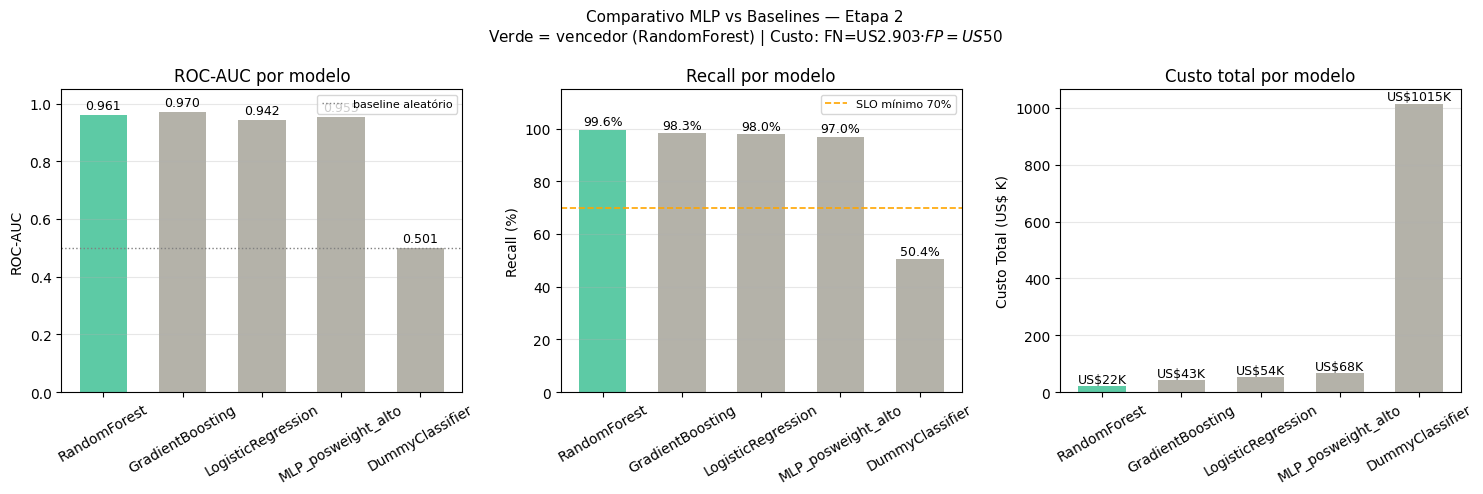

✓ Gráfico salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\tech_challenge\tech_challenge_1_fiap_mlops\reports\figures\comparativo_modelos_etapa2.png


In [57]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
models_order = df_comp["model"].tolist()
colors = ["#5DCAA5" if m == winner["model"] else "#B4B2A9" for m in models_order]

# ── ROC-AUC ───────────────────────────────────────────────────────────────────
ax = axes[0]
bars = ax.bar(models_order, df_comp["roc_auc"], color=colors, width=0.6)
ax.set_ylim(0, 1.05)
ax.set_ylabel("ROC-AUC")
ax.set_title("ROC-AUC por modelo")
ax.tick_params(axis="x", rotation=30)
ax.axhline(0.5, color="gray", ls=":", lw=1, label="baseline aleatório")
ax.legend(fontsize=8)
ax.grid(axis="y", alpha=0.3)
for bar, val in zip(bars, df_comp["roc_auc"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"{val:.3f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

# ── Recall ────────────────────────────────────────────────────────────────────
ax = axes[1]
bars = ax.bar(models_order, df_comp["recall"] * 100, color=colors, width=0.6)
ax.set_ylim(0, 115)
ax.set_ylabel("Recall (%)")
ax.set_title("Recall por modelo")
ax.tick_params(axis="x", rotation=30)
ax.axhline(70, color="orange", ls="--", lw=1.2, label="SLO mínimo 70%")
ax.legend(fontsize=8)
ax.grid(axis="y", alpha=0.3)
for bar, val in zip(bars, df_comp["recall"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{val:.1%}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

# ── Custo Total ───────────────────────────────────────────────────────────────
ax = axes[2]
bars = ax.bar(models_order, df_comp["cost_total_usd"] / 1e3, color=colors, width=0.6)
ax.set_ylabel("Custo Total (US$ K)")
ax.set_title("Custo total por modelo")
ax.tick_params(axis="x", rotation=30)
ax.grid(axis="y", alpha=0.3)
for bar, val in zip(bars, df_comp["cost_total_usd"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"US${val / 1e3:.0f}K",
        ha="center",
        va="bottom",
        fontsize=9,
    )

fig.suptitle(
    "Comparativo MLP vs Baselines — Etapa 2\n"
    f"Verde = vencedor ({winner['model']}) | Custo: FN=US$2.903 · FP=US$50",
    fontsize=11,
)
fig.tight_layout()

chart_path = figs_dir / "comparativo_modelos_etapa2.png"
fig.savefig(chart_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ Gráfico salvo: {chart_path}")

## 17. Salvar artefatos finais e fechar o run pai no MLflow

In [58]:
# ── Salvar CSV da tabela comparativa ─────────────────────────────────────────
comparison_path = PROJECT_ROOT / "models" / "model_comparison_etapa2.csv"
df_comp.to_csv(comparison_path, index=False)

# ── Reabrir run pai para logar artefatos e métricas finais ────────────────────
mlflow.end_run()  # garante que não há run ativo

with mlflow.start_run(run_id=parent_run_id):
    # Artefatos
    mlflow.log_artifact(str(comparison_path), "reports")
    mlflow.log_artifact(str(chart_path), "plots")

    # Métricas do vencedor no run pai (facilita comparação na UI)
    mlflow.log_metrics(
        {
            "winner_roc_auc": winner["roc_auc"],
            "winner_pr_auc": winner["pr_auc"],
            "winner_recall": winner["recall"],
            "winner_f1": winner["f1"],
            "winner_cost_total_usd": winner["cost_total_usd"],
            "winner_fn": float(winner["fn"]),
        }
    )
    mlflow.log_param("winner_model", winner["model"])
    mlflow.set_tag("etapa", "2_completa")

logger.info(
    "Etapa 2 concluída | vencedor=%s | custo=US$%.0f | recall=%.3f",
    winner["model"],
    winner["cost_total_usd"],
    winner["recall"],
)

print(f"\n✓ CSV salvo       : {comparison_path}")
print("✓ Gráfico logado  : comparativo_modelos_etapa2.png")
print(f"✓ Run pai fechado : {parent_run_id}")
print(f"\n{'=' * 55}")
print("ETAPA 2 CONCLUÍDA")
print(f"{'=' * 55}")
print("Entregáveis:")
print("  [x] MLP treinada com early stopping e batching")
print("  [x] 3 runs MLP otimizados no MLflow")
print("  [x] 4 baselines treinados e logados no MLflow")
print(f"  [x] Tabela comparativa (≥4 métricas) → {comparison_path.name}")
print("  [x] Análise de trade-off FP×FN com custos reais")
print("  [x] Gráfico comparativo salvo e logado")
print(f"\nVencedor: {winner['model']}")
print(f"  ROC-AUC : {winner['roc_auc']:.4f}")
print(f"  PR-AUC  : {winner['pr_auc']:.4f}")
print(f"  Recall  : {winner['recall']:.1%}")
print(f"  F1      : {winner['f1']:.3f}")
print(f"  Custo   : US${winner['cost_total_usd']:,.0f}")
print("\nPróximo: Etapa 3 — Refatoração src/, FastAPI, testes automatizados")

00:19:49 | INFO | Etapa 2 concluída | vencedor=RandomForest | custo=US$21959 | recall=0.996
INFO:04_vab_treinamento_mlp:Etapa 2 concluída | vencedor=RandomForest | custo=US$21959 | recall=0.996



✓ CSV salvo       : C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\tech_challenge\tech_challenge_1_fiap_mlops\models\model_comparison_etapa2.csv
✓ Gráfico logado  : comparativo_modelos_etapa2.png
✓ Run pai fechado : 9df59304b0e3473da8e3ee83d40d5e41

ETAPA 2 CONCLUÍDA
Entregáveis:
  [x] MLP treinada com early stopping e batching
  [x] 3 runs MLP otimizados no MLflow
  [x] 4 baselines treinados e logados no MLflow
  [x] Tabela comparativa (≥4 métricas) → model_comparison_etapa2.csv
  [x] Análise de trade-off FP×FN com custos reais
  [x] Gráfico comparativo salvo e logado

Vencedor: RandomForest
  ROC-AUC : 0.9615
  PR-AUC  : 0.9579
  Recall  : 99.6%
  F1      : 0.838
  Custo   : US$21,959

Próximo: Etapa 3 — Refatoração src/, FastAPI, testes automatizados
